In [3]:
# --------------------------- 
# 📦 INSTALL REQUIRED PACKAGES 
# --------------------------- 
# Run these in a Jupyter cell or terminal first: 
# !pip install pandas matplotlib seaborn numpy  

# --------------------------- 
# 📊 ENHANCED DATA VISUALIZATION SCRIPT 
# --------------------------- 
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import os
import pathlib

# Set overall style and color palette
sns.set(style="whitegrid")
plt.rcParams.update({'font.size': 11})
custom_palette = sns.color_palette("viridis", 4)
sns.set_palette(custom_palette)

# Get current directory in a notebook-compatible way
current_dir = pathlib.Path().resolve()
project_root = current_dir.parent.parent  # Go up one level 

# Define file paths relative to project root
file_paths = {
    "Claude Response + Claude Rating": os.path.join(project_root, "Ratings/Empathy/claude_response_claude_rating.csv"),
    "Claude Response + GPT Rating": os.path.join(project_root, "Ratings/Empathy/claude_response_gpt_rating.csv"),
    "GPT Response + Claude Rating": os.path.join(project_root, "Ratings/Empathy/gpt_response_claude_rating.csv"),
    "GPT Response + GPT Rating": os.path.join(project_root, "Ratings/Empathy/gpt_response_gpt_rating.csv")
}

# Load data into a dictionary
dataframes = {}
for label, path in file_paths.items():
    df = pd.read_csv(path)
    df["Source"] = label  # Track origin for visualization
    dataframes[label] = df

# Combine all into one DataFrame
combined_df = pd.concat(dataframes.values(), ignore_index=True)

# Create output directory
output_folder = os.path.join(project_root, "Scoring_Charts/")
os.makedirs(output_folder, exist_ok=True)

# -------------------------
# 1. BASIC SCORE DISTRIBUTIONS
# -------------------------

# 1.1 Affective Empathy Score Distribution
plt.figure(figsize=(12, 6))
sns.boxplot(x="Source", y="Affective Empathy Score", data=combined_df)
plt.title("Affective Empathy Score Distribution by Source", fontweight='bold')
plt.xticks(rotation=15)
plt.tight_layout()
plt.savefig(os.path.join(output_folder, "affective_score_distribution.png"), dpi=300)
plt.close()

# 1.2 Cognitive Understanding Score Distribution
plt.figure(figsize=(12, 6))
sns.boxplot(x="Source", y="Cognitive Understanding Score", data=combined_df)
plt.title("Cognitive Understanding Score Distribution by Source", fontweight='bold')
plt.xticks(rotation=15)
plt.tight_layout()
plt.savefig(os.path.join(output_folder, "cognitive_score_distribution.png"), dpi=300)
plt.close()

# 1.3 Violin plots for better visualization of distribution shapes
plt.figure(figsize=(14, 7))
plt.subplot(1, 2, 1)
sns.violinplot(x="Source", y="Affective Empathy Score", data=combined_df, inner="quartile")
plt.title("Affective Empathy Score Distribution", fontweight='bold')
plt.xticks(rotation=20, ha='right')

plt.subplot(1, 2, 2)
sns.violinplot(x="Source", y="Cognitive Understanding Score", data=combined_df, inner="quartile")
plt.title("Cognitive Understanding Score Distribution", fontweight='bold')
plt.xticks(rotation=20, ha='right')

plt.tight_layout()
plt.savefig(os.path.join(output_folder, "score_distributions_violin.png"), dpi=300)
plt.close()

# -------------------------
# 2. DEMOGRAPHIC ANALYSIS
# -------------------------

# 2.1 Scores by Gender
plt.figure(figsize=(14, 7))
plt.subplot(1, 2, 1)
sns.boxplot(x="gender", y="Affective Empathy Score", hue="Source", data=combined_df)
plt.title("Affective Empathy Score by Gender", fontweight='bold')
plt.legend(title="Source", loc="upper right", bbox_to_anchor=(1.15, 1))

plt.subplot(1, 2, 2)
sns.boxplot(x="gender", y="Cognitive Understanding Score", hue="Source", data=combined_df)
plt.title("Cognitive Understanding Score by Gender", fontweight='bold')
plt.legend([],[], frameon=False)  # Hide redundant legend

plt.tight_layout()
plt.savefig(os.path.join(output_folder, "scores_by_gender.png"), dpi=300)
plt.close()

# 2.2 Process age into groups (if it's continuous)
try:
    # Check if age is already categorical or needs grouping
    if combined_df['age'].dtype == 'object':
        # If age is already a string/category, use it as is
        age_groups = combined_df['age']
    else:
        # If age is numerical, create age groups
        bins = [0, 18, 35, 50, 65, 100]
        labels = ['<18', '18-34', '35-49', '50-64', '65+']
        combined_df['age_group'] = pd.cut(combined_df['age'], bins=bins, labels=labels, right=False)
        age_groups = combined_df['age_group']
        
    # Now plot with the appropriate age variable
    age_var = 'age_group' if 'age_group' in combined_df.columns else 'age'
    
    plt.figure(figsize=(14, 7))
    plt.subplot(1, 2, 1)
    sns.barplot(x=age_var, y="Affective Empathy Score", hue="Source", data=combined_df, ci="sd")
    plt.title("Affective Empathy by Age", fontweight='bold')
    plt.xticks(rotation=0)
    plt.legend(title="Source", loc="upper right", bbox_to_anchor=(1.3, 1))
    
    plt.subplot(1, 2, 2)
    sns.barplot(x=age_var, y="Cognitive Understanding Score", hue="Source", data=combined_df, ci="sd")
    plt.title("Cognitive Understanding by Age", fontweight='bold')
    plt.xticks(rotation=0)
    plt.legend([],[], frameon=False)  # Hide redundant legend
    
    plt.tight_layout()
    plt.savefig(os.path.join(output_folder, "scores_by_age.png"), dpi=300)
    plt.close()
except Exception as e:
    print(f"Skipping age analysis due to: {e}")

# 2.3 Scores by Education Level
plt.figure(figsize=(14, 7))
plt.subplot(1, 2, 1)
sns.barplot(x="education", y="Affective Empathy Score", hue="Source", data=combined_df, ci="sd")
plt.title("Affective Empathy by Education", fontweight='bold')
plt.xticks(rotation=30, ha='right')
plt.legend(title="Source", loc="upper right", bbox_to_anchor=(1.3, 1))

plt.subplot(1, 2, 2)
sns.barplot(x="education", y="Cognitive Understanding Score", hue="Source", data=combined_df, ci="sd")
plt.title("Cognitive Understanding by Education", fontweight='bold')
plt.xticks(rotation=30, ha='right')
plt.legend([],[], frameon=False)  # Hide redundant legend

plt.tight_layout()
plt.savefig(os.path.join(output_folder, "scores_by_education.png"), dpi=300)
plt.close()

# 2.4 Scores by Ethnicity
plt.figure(figsize=(16, 8))
plt.subplot(1, 2, 1)
sns.barplot(x="ethnicity", y="Affective Empathy Score", hue="Source", data=combined_df, ci="sd")
plt.title("Affective Empathy by Ethnicity", fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.legend(title="Source", loc="upper right")

plt.subplot(1, 2, 2)
sns.barplot(x="ethnicity", y="Cognitive Understanding Score", hue="Source", data=combined_df, ci="sd")
plt.title("Cognitive Understanding by Ethnicity", fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.legend([],[], frameon=False)  # Hide redundant legend

plt.tight_layout()
plt.savefig(os.path.join(output_folder, "scores_by_ethnicity.png"), dpi=300)
plt.close()

# -------------------------
# 3. CLINICAL ANALYSIS
# -------------------------

# 3.1 Scores by Diagnosis
plt.figure(figsize=(16, 8))
plt.subplot(1, 2, 1)
sns.barplot(x="diagnosis", y="Affective Empathy Score", hue="Source", data=combined_df, ci="sd")
plt.title("Affective Empathy by Diagnosis", fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.legend(title="Source", loc="upper right")

plt.subplot(1, 2, 2)
sns.barplot(x="diagnosis", y="Cognitive Understanding Score", hue="Source", data=combined_df, ci="sd")
plt.title("Cognitive Understanding by Diagnosis", fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.legend([],[], frameon=False)  # Hide redundant legend

plt.tight_layout()
plt.savefig(os.path.join(output_folder, "scores_by_diagnosis.png"), dpi=300)
plt.close()

# 3.2 Scores by Treatment Outlook (using violin plots for better distribution visualization)
plt.figure(figsize=(16, 8))
plt.subplot(1, 2, 1)
sns.violinplot(x="treatment_outlook", y="Affective Empathy Score", hue="Source", data=combined_df, split=True)
plt.title("Affective Empathy by Treatment Outlook", fontweight='bold')
plt.xticks(rotation=30, ha='right')
plt.legend(title="Source", loc="upper right")

plt.subplot(1, 2, 2)
sns.violinplot(x="treatment_outlook", y="Cognitive Understanding Score", hue="Source", data=combined_df, split=True)
plt.title("Cognitive Understanding by Treatment Outlook", fontweight='bold')
plt.xticks(rotation=30, ha='right')
plt.legend([],[], frameon=False)  # Hide redundant legend

plt.tight_layout()
plt.savefig(os.path.join(output_folder, "scores_by_treatment_outlook.png"), dpi=300)
plt.close()

# -------------------------
# 4. CORRELATION ANALYSIS
# -------------------------

# 4.1 Correlation between Affective and Cognitive Scores
plt.figure(figsize=(10, 8))
sns.scatterplot(x="Affective Empathy Score", y="Cognitive Understanding Score", 
                hue="Source", size="diagnosis", sizes=(50, 200),
                data=combined_df, alpha=0.7)
sns.regplot(x="Affective Empathy Score", y="Cognitive Understanding Score", 
            data=combined_df, scatter=False, color="gray")

# Calculate and display correlation coefficient
corr = combined_df[['Affective Empathy Score', 'Cognitive Understanding Score']].corr().iloc[0,1]
plt.annotate(f"Correlation: {corr:.2f}", xy=(0.05, 0.95), xycoords='axes fraction', 
             fontsize=12, fontweight='bold', bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="gray", alpha=0.8))

plt.title("Correlation between Affective Empathy and Cognitive Understanding", fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(output_folder, "affective_vs_cognitive_correlation.png"), dpi=300)
plt.close()

# 4.2 Correlation Heatmap of All Numerical Variables
# First identify numerical columns
numerical_cols = combined_df.select_dtypes(include=['int64', 'float64']).columns.tolist()

# Filter to only include meaningful numerical variables (exclude IDs, etc.)
score_cols = [col for col in numerical_cols if 'Score' in col or col in ['age']]

if len(score_cols) > 1:  # Only create if we have multiple numerical columns
    plt.figure(figsize=(10, 8))
    correlation_matrix = combined_df[score_cols].corr()
    mask = np.triu(np.ones_like(correlation_matrix, dtype=bool))  # Mask upper triangle
    sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap="coolwarm", 
                mask=mask, vmin=-1, vmax=1, center=0, square=True, linewidths=.5)
    plt.title("Correlation Heatmap of Score Variables", fontweight='bold')
    plt.tight_layout()
    plt.savefig(os.path.join(output_folder, "correlation_heatmap.png"), dpi=300)
    plt.close()

# -------------------------
# 5. ADVANCED VISUALIZATIONS
# -------------------------

# 5.1 Facet Grid for Multi-dimensional Analysis
# Create a facet grid to show Affective scores by gender and diagnosis
if len(combined_df['diagnosis'].unique()) <= 4:  # Only if we have a reasonable number of diagnoses
    g = sns.FacetGrid(combined_df, col="diagnosis", row="gender", height=4, aspect=1.2)
    g.map_dataframe(sns.boxplot, x="Source", y="Affective Empathy Score")
    g.set_axis_labels("", "Affective Empathy Score")
    g.set_titles(col_template="{col_name}", row_template="{row_name}")
    g.fig.subplots_adjust(top=0.9)
    g.fig.suptitle("Affective Empathy Scores by Gender and Diagnosis", fontsize=16, fontweight='bold')
    plt.savefig(os.path.join(output_folder, "facet_grid_analysis.png"), dpi=300)
    plt.close()

# 5.2 Summary Statistics Table
# Create a grouped summary statistics table and save as CSV
summary_stats = combined_df.groupby(['Source']).agg({
    'Affective Empathy Score': ['mean', 'std', 'min', 'max', 'count'],
    'Cognitive Understanding Score': ['mean', 'std', 'min', 'max']
})
summary_stats.columns = ['_'.join(col).strip() for col in summary_stats.columns.values]
summary_stats.reset_index().to_csv(os.path.join(output_folder, "summary_statistics.csv"), index=False)

# Also save a version split by gender
gender_summary = combined_df.groupby(['Source', 'gender']).agg({
    'Affective Empathy Score': ['mean', 'std', 'count'],
    'Cognitive Understanding Score': ['mean', 'std']
})
gender_summary.columns = ['_'.join(col).strip() for col in gender_summary.columns.values]
gender_summary.reset_index().to_csv(os.path.join(output_folder, "gender_summary_statistics.csv"), index=False)

# 5.3 Radar Chart for Model Performance Comparison
# This visualization compares models across multiple metrics in a radar chart
try:
    # Calculate mean scores by Source and various categories
    mean_by_gender = combined_df.groupby(['Source', 'gender'])['Affective Empathy Score'].mean().unstack()
    mean_by_diagnosis = combined_df.groupby(['Source'])['Affective Empathy Score'].mean()
    mean_cognitive = combined_df.groupby(['Source'])['Cognitive Understanding Score'].mean()
    
    # Prepare data for radar chart
    categories = ['Overall Affective', 'Cognitive Understanding'] + list(mean_by_gender.columns)
    
    # Set up the radar chart
    plt.figure(figsize=(10, 10))
    
    # Number of variables
    N = len(categories)
    
    # Create angle for each category
    angles = [n / float(N) * 2 * np.pi for n in range(N)]
    angles += angles[:1]  # Close the loop
    
    # Initialize the plot
    ax = plt.subplot(111, polar=True)
    
    # Draw one axis per variable and add labels
    plt.xticks(angles[:-1], categories, size=12)
    
    # Draw y-axis labels (not too many to avoid cluttering)
    ax.set_rlabel_position(0)
    plt.yticks([2, 4, 6, 8, 10], ["2", "4", "6", "8", "10"], color="grey", size=10)
    plt.ylim(0, 10)
    
    # Plot each Source
    for source in mean_by_diagnosis.index:
        # Collect values for this Source
        values = [mean_by_diagnosis[source], mean_cognitive[source]]
        
        # Add gender-specific values
        for gender in mean_by_gender.columns:
            values.append(mean_by_gender.loc[source, gender])
            
        # Close the loop
        values += values[:1]
        
        # Plot values
        ax.plot(angles, values, linewidth=2, linestyle='solid', label=source)
        ax.fill(angles, values, alpha=0.1)
    
    # Add legend
    plt.legend(loc='upper right', bbox_to_anchor=(0.1, 0.1))
    plt.title("Model Performance Comparison Across Dimensions", size=18, fontweight='bold', pad=20)
    
    plt.tight_layout()
    plt.savefig(os.path.join(output_folder, "model_comparison_radar.png"), dpi=300)
    plt.close()
except Exception as e:
    print(f"Skipping radar chart due to: {e}")

print(f"✅ Enhanced visualizations saved in: {output_folder}")
print(f"📊 Generated {len(os.listdir(output_folder))} visualization files")

# Summary of visualizations created:
print("\nVisualization Summary:")
print("1️⃣ Basic distributions (box plots, violin plots)")
print("2️⃣ Demographic analysis (gender, age, education, ethnicity)")
print("3️⃣ Clinical analysis (diagnosis, treatment outlook)")
print("4️⃣ Correlation analysis (scatter plots, heatmaps)")
print("5️⃣ Advanced visualizations (facet grids, radar charts)")
print("6️⃣ Summary statistics tables (CSV files)")

/var/folders/c0/44p3b4xx4v956042lj_vp7z80000gn/T/ipykernel_33283/303912204.py:125: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar='sd'` for the same effect.

  sns.barplot(x=age_var, y="Affective Empathy Score", hue="Source", data=combined_df, ci="sd")
/var/folders/c0/44p3b4xx4v956042lj_vp7z80000gn/T/ipykernel_33283/303912204.py:131: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar='sd'` for the same effect.

  sns.barplot(x=age_var, y="Cognitive Understanding Score", hue="Source", data=combined_df, ci="sd")
/var/folders/c0/44p3b4xx4v956042lj_vp7z80000gn/T/ipykernel_33283/303912204.py:145: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar='sd'` for the same effect.

  sns.barplot(x="education", y="Affective Empathy Score", hue="Source", data=combined_df, ci="sd")
/var/folders/c0/44p3b4xx4v956042lj_vp7z80000gn/T/ipykernel_33283/303912204.py:151: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar='sd'` for the same effect.

 

✅ Enhanced visualizations saved in: /Users/jianzhouyao/AI4Good/Scoring_Charts/
📊 Generated 26 visualization files

Visualization Summary:
1️⃣ Basic distributions (box plots, violin plots)
2️⃣ Demographic analysis (gender, age, education, ethnicity)
3️⃣ Clinical analysis (diagnosis, treatment outlook)
4️⃣ Correlation analysis (scatter plots, heatmaps)
5️⃣ Advanced visualizations (facet grids, radar charts)
6️⃣ Summary statistics tables (CSV files)


In [45]:
import os
import pathlib
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ==============================
# Global plotting style
# ==============================
sns.set(style="whitegrid")
sns.set_context("talk", font_scale=1.3)

plt.rcParams.update({
    "font.size": 24,
    "axes.labelsize": 24,
    "xtick.labelsize": 22,
    "ytick.labelsize": 22,
    "legend.fontsize": 20,
    "figure.constrained_layout.use": True,  # ok to keep; we'll still call tight_layout with rect
})

custom_palette = sns.color_palette("viridis", 4)
sns.set_palette(custom_palette)

FIGSIZE = (14, 7)
DPI = 300
XTICK_ROT = 30

# ==============================
# Paths & data loading
# ==============================
current_dir = pathlib.Path().resolve()
project_root = current_dir.parent.parent

demographics_path = project_root / "Prompts_And_Response" / "initial_prompts.csv"
prompts_df = pd.read_csv(
    demographics_path,
    usecols=["Prompt Number", "age", "ethnicity", "gender", "education", "diagnosis", "treatment_outlook"]
)
prompts_df["Prompt Number"] = prompts_df["Prompt Number"].astype(int)

ratings_folder = project_root / "Ratings" / "Empathy"
file_paths = {
    "Claude Response + Claude Rating": ratings_folder / "claude_response_claude_rating.csv",
    "Claude Response + GPT Rating":    ratings_folder / "claude_response_gpt_rating.csv",
    "GPT Response + Claude Rating":    ratings_folder / "gpt_response_claude_rating.csv",
    "GPT Response + GPT Rating":       ratings_folder / "gpt_response_gpt_rating.csv",
}

frames = []
for label, path in file_paths.items():
    df = pd.read_csv(path)
    # Drop any stale demo cols, then merge clean ones
    df = df.drop(columns=["age","ethnicity","gender","education","diagnosis","treatment_outlook"], errors="ignore")
    df = df.merge(prompts_df, on="Prompt Number", how="left")
    df["Source"] = label
    frames.append(df)

combined_df = pd.concat(frames, ignore_index=True)

# ==============================
# Clean/convert + canonicalize column names
# ==============================
combined_df["age"] = pd.to_numeric(combined_df["age"], errors="coerce")
combined_df.columns = combined_df.columns.str.strip()

# Map any known variants to canonical names
colmap_candidates = {
    # affective
    "Affective Empathy Score": "Affective Empathy",
    "Affective Empathy": "Affective Empathy",
    # cognitive
    "Cognitive Understanding Score": "Cognitive Empathy",
    "Cognitive Empathy Score": "Cognitive Empathy",
    "Cognitive Empathy": "Cognitive Empathy",
}
rename_actual = {c: colmap_candidates[c] for c in combined_df.columns if c in colmap_candidates}
combined_df = combined_df.rename(columns=rename_actual)

# Sanity check
required_cols = {"Affective Empathy", "Cognitive Empathy"}
missing = required_cols - set(combined_df.columns)
if missing:
    raise ValueError(
        f"Missing required score columns after renaming: {missing}\n"
        f"Available columns: {list(combined_df.columns)}"
    )

# ==============================
# Abbreviations
# ==============================
# Legend (hue) abbreviations for evaluator/response source
source_short_map = {
    "Claude Response + Claude Rating": "C→C",
    "Claude Response + GPT Rating":    "C→G",
    "GPT Response + Claude Rating":    "G→C",
    "GPT Response + GPT Rating":       "G→G",
}
combined_df["SourceShort"] = combined_df["Source"].map(source_short_map).fillna(combined_df["Source"])
source_short_order = ["C→C", "C→G", "G→C", "G→G"]

# Education & Diagnosis (x-axis) abbreviations
edu_labels_abbrev = {
    "high school diploma or lower": "HS",
    "university degree": "Univ",
    "medical degree": "Med",
}
diag_labels_abbrev = {
    "pancreatic cancer": "PanCan",
    "Chronic Ischemic Heart Disease": "CIHD",
    "obesity": "Obes",
    "Alzheimer’s": "Alz",
}
combined_df["education_abbrev"] = combined_df["education"].map(edu_labels_abbrev).fillna(combined_df["education"])
combined_df["diagnosis_abbrev"] = combined_df["diagnosis"].map(diag_labels_abbrev).fillna(combined_df["diagnosis"])

# ==============================
# Output folder
# ==============================
output_folder = project_root / "Scoring_Charts"
os.makedirs(output_folder, exist_ok=True)

# ==============================
# Helper to draw a 1×2 figure with a bottom-centered legend
# ==============================
def two_panel_with_bottom_legend(
    data, x1, x2, order1=None, order2=None, xlabel="",
    y1="Affective Empathy", y2="Cognitive Empathy",
    hue="SourceShort", hue_order=None, filename="figure.png"
):
    fig = plt.figure(figsize=FIGSIZE)

    # Left panel
    ax1 = plt.subplot(1, 2, 1)
    sns.barplot(
        x=x1, y=y1, hue=hue, hue_order=hue_order, data=data, ci="sd", order=order1, ax=ax1
    )
    ax1.set_xlabel(xlabel)
    ax1.set_ylabel(y1)
    ax1.set_xticklabels(ax1.get_xticklabels(), rotation=XTICK_ROT, ha="right")

    # Right panel
    ax2 = plt.subplot(1, 2, 2)
    sns.barplot(
        x=x2, y=y2, hue=hue, hue_order=hue_order, data=data, ci="sd", order=order2, ax=ax2
    )
    ax2.set_xlabel(xlabel)
    ax2.set_ylabel(y2)
    ax2.set_xticklabels(ax2.get_xticklabels(), rotation=XTICK_ROT, ha="right")

    # Remove per-axis legends
    if ax1.get_legend() is not None:
        ax1.get_legend().remove()
    if ax2.get_legend() is not None:
        ax2.get_legend().remove()

    # Shared legend below, compact on one row
    handles, labels = ax1.get_legend_handles_labels()
    fig.legend(handles, labels, loc="lower center", ncol=4, frameon=False)

    # Leave room at bottom for the legend
    plt.tight_layout(rect=[0, 0.12, 1, 1])

    # Save & close
    path = output_folder / filename
    plt.savefig(path, dpi=DPI, bbox_inches="tight")
    plt.close()
    return path

# ==============================
# (1) By Age Group (legend at bottom)
# ==============================
bins   = [0, 18, 50, 65, 100]
labels = ['<18', '18-49', '50-64', '65+']
combined_df['age_group'] = pd.cut(combined_df['age'], bins=bins, labels=labels, right=False)

age_path = two_panel_with_bottom_legend(
    combined_df, x1="age_group", x2="age_group",
    order1=labels, order2=labels, xlabel="Age Group",
    hue_order=source_short_order, filename="scores_by_age.png"
)

# ==============================
# (2) By Education (x labels abbreviated; legend bottom)
# ==============================
edu_path = two_panel_with_bottom_legend(
    combined_df, x1="education_abbrev", x2="education_abbrev",
    order1=["HS","Univ","Med"], order2=["HS","Univ","Med"], xlabel="Education",
    hue_order=source_short_order, filename="scores_by_education.png"
)

# ==============================
# (3) By Ethnicity (legend bottom)
# ==============================
eth_path = two_panel_with_bottom_legend(
    combined_df, x1="ethnicity", x2="ethnicity",
    xlabel="Ethnicity", hue_order=source_short_order,
    filename="scores_by_ethnicity.png"
)

# ==============================
# (4) By Diagnosis (x labels abbreviated; legend bottom)
# ==============================
dx_path = two_panel_with_bottom_legend(
    combined_df, x1="diagnosis_abbrev", x2="diagnosis_abbrev",
    order1=["PanCan","CIHD","Obes","Alz"], order2=["PanCan","CIHD","Obes","Alz"],
    xlabel="Diagnosis", hue_order=source_short_order, filename="scores_by_diagnosis.png"
)

print("✅ Saved A–D figures:")
for p in [age_path, edu_path, eth_path, dx_path]:
    print(" -", p)

# ==============================
# (5) Gender Bias Visualization (Female − Male) — legend ABOVE (compact)
# ==============================
_df = combined_df.copy()
_df["gender_norm"] = _df["gender"].astype(str).str.strip().str.lower()
_df["SourceShort"] = _df["Source"].map(source_short_map).fillna(_df["Source"])

bias_wide = (
    _df
    .groupby(["SourceShort", "gender_norm"])[["Affective Empathy", "Cognitive Empathy"]]
    .mean()
    .unstack(level=-1)
)

aff_f = bias_wide[("Affective Empathy", "female")]
aff_m = bias_wide[("Affective Empathy", "male")]
cog_f = bias_wide[("Cognitive Empathy", "female")]
cog_m = bias_wide[("Cognitive Empathy", "male")]

bias = pd.DataFrame({
    "Affective": aff_f - aff_m,
    "Cognitive": cog_f - cog_m,
}).reindex([lab for lab in source_short_order if lab in bias_wide.index])

print("Gender Bias (Female - Male):")
print(bias.round(3))

plt.figure(figsize=FIGSIZE)
ax = plt.gca()

# Bars
bar_containers = bias.plot(
    kind="bar",
    ax=ax,
    color=[custom_palette[0], custom_palette[1]],
    rot=0,
    width=0.8,
    legend=False
).containers

# Reference line
ax.axhline(0, color="black", linewidth=1.2, linestyle="--", alpha=0.7)

# Ticks & labels
ax.set_xticklabels(bias.index, rotation=XTICK_ROT, ha="right")
ax.set_ylabel("Female − Male (mean difference)")
ax.set_xlabel("")

# Value labels
for container in bar_containers:
    ax.bar_label(container, fmt="%.2f", padding=3)

# Put legend ABOVE the axes (outside) and reserve top space
handles = list(bar_containers)
labels  = bias.columns.tolist()
ax.legend(handles=handles, labels=labels,
          loc="upper center", bbox_to_anchor=(0.5, 1.20),
          ncol=2, frameon=False)

# Leave room at the top for legend
plt.tight_layout(rect=[0, 0, 1, 0.88])

gb_png = output_folder / "gender_bias_difference.png"
gb_pdf = output_folder / "gender_bias_difference.pdf"
plt.savefig(gb_png, dpi=DPI, bbox_inches="tight")
plt.savefig(gb_pdf, bbox_inches="tight")
plt.close()

print("✅ Saved:", gb_png)


✅ Saved A–D figures:
 - /Users/jianzhouyao/AI4Good/Scoring_Charts/scores_by_age.png
 - /Users/jianzhouyao/AI4Good/Scoring_Charts/scores_by_education.png
 - /Users/jianzhouyao/AI4Good/Scoring_Charts/scores_by_ethnicity.png
 - /Users/jianzhouyao/AI4Good/Scoring_Charts/scores_by_diagnosis.png
Gender Bias (Female - Male):
             Affective  Cognitive
SourceShort                      
C→C              0.090      0.013
C→G              0.051      0.103
G→C              0.013     -0.026
G→G              0.000      0.064
✅ Saved: /Users/jianzhouyao/AI4Good/Scoring_Charts/gender_bias_difference.png


In [41]:
# ==============================
# Gender Bias Visualization (Female − Male) — unified style
# ==============================

# Normalize gender labels for robustness
_df = combined_df.copy()
_df["gender_norm"] = _df["gender"].astype(str).str.strip().str.lower()

# Compute mean scores by evaluator × gender
bias_wide = (
    _df
    .groupby(["Source", "gender_norm"])[["Affective Empathy", "Cognitive Empathy"]]
    .mean()
    .unstack(level=-1)
)

# Calculate Female - Male differences (per evaluator)
aff_f = bias_wide[("Affective Empathy", "female")]
aff_m = bias_wide[("Affective Empathy", "male")]
cog_f = bias_wide[("Cognitive Empathy", "female")]
cog_m = bias_wide[("Cognitive Empathy", "male")]

bias = pd.DataFrame({
    "Affective": aff_f - aff_m,
    "Cognitive": cog_f - cog_m,
})

# Order rows consistently with other figures (if present)
row_order = [
    "Claude Response + Claude Rating",
    "Claude Response + GPT Rating",
    "GPT Response + Claude Rating",
    "GPT Response + GPT Rating",
]
bias = bias.reindex([r for r in row_order if r in bias.index])

# Print values to console for inspection
print("Gender Bias (Female - Male):")
print(bias.round(3))

# ==============================
# Plot
# ==============================
plt.figure(figsize=FIGSIZE)
ax = plt.gca()

# Barplot (two columns = two bias types)
bar_containers = bias.plot(
    kind="bar",
    ax=ax,
    color=[custom_palette[0], custom_palette[1]],
    rot=0,
    width=0.8,
    legend=False
).containers

# Add horizontal zero reference
ax.axhline(0, color="black", linewidth=1.2, linestyle="--", alpha=0.7)

# Format x-axis
ax.set_xticklabels(bias.index, rotation=XTICK_ROT, ha="right")

# Legend outside — no "Source" title anymore
handles = [c for c in bar_containers]
labels  = bias.columns.tolist()
ax.legend(handles=handles, labels=labels,
          bbox_to_anchor=(1.02, 1), loc="upper left", borderaxespad=0)

# Axis labels
ax.set_ylabel("Female − Male (mean difference)")
ax.set_xlabel("")  # remove "Source" label for a cleaner look

# Add numeric labels on bars
for container in bar_containers:
    ax.bar_label(container, fmt="%.2f", padding=3)

# Save plots
plt.tight_layout()
plt.savefig(output_folder / "gender_bias_difference.png", dpi=DPI, bbox_inches="tight")
plt.savefig(output_folder / "gender_bias_difference.pdf", bbox_inches="tight")
plt.close()

print("✅ Saved:", output_folder / "gender_bias_difference.png")


Gender Bias (Female - Male):
                                 Affective  Cognitive
Source                                               
Claude Response + Claude Rating      0.090      0.013
Claude Response + GPT Rating         0.051      0.103
GPT Response + Claude Rating         0.013     -0.026
GPT Response + GPT Rating            0.000      0.064
✅ Saved: /Users/jianzhouyao/AI4Good/Scoring_Charts/gender_bias_difference.png


In [13]:
from scipy.stats import ttest_ind

# Perform t-tests for Female vs Male per Source and Score Type
results = []
score_types = {
    "Affective Bias": "Affective Empathy Score",
    "Cognitive Bias": "Cognitive Understanding Score"
}

for source in combined_df["Source"].unique():
    df_sub = combined_df[combined_df["Source"] == source]
    for bias_label, score_col in score_types.items():
        female_scores = df_sub[df_sub["gender"] == "female"][score_col]
        male_scores   = df_sub[df_sub["gender"] == "male"][score_col]
        
        t_stat, p_value = ttest_ind(
            female_scores, male_scores, equal_var=False, nan_policy="omit"
        )
        female_mean = female_scores.mean()
        male_mean   = male_scores.mean()
        
        results.append({
            "Source": source,
            "Score Type": bias_label,
            "Female Mean": round(female_mean, 3),
            "Male Mean": round(male_mean, 3),
            "Bias (F - M)": round(female_mean - male_mean, 3),
            "t-statistic": round(t_stat, 3),
            "p-value": round(p_value, 4),
            "Significant (p<0.05)": "Yes" if p_value < 0.05 else "No"
        })

# Create DataFrame and export
bias_test_df = pd.DataFrame(results)
bias_test_df.to_csv(output_folder / "gender_bias_significance_tests.csv", index=False)

# Print to console
print("\n📊 Gender Bias T-Test Results:")
print(bias_test_df)



📊 Gender Bias T-Test Results:
                            Source      Score Type  Female Mean  Male Mean  \
0  Claude Response + Claude Rating  Affective Bias        2.128      2.038   
1  Claude Response + Claude Rating  Cognitive Bias        2.872      2.859   
2     Claude Response + GPT Rating  Affective Bias        2.372      2.321   
3     Claude Response + GPT Rating  Cognitive Bias        2.885      2.782   
4     GPT Response + Claude Rating  Affective Bias        2.346      2.333   
5     GPT Response + Claude Rating  Cognitive Bias        2.744      2.769   
6        GPT Response + GPT Rating  Affective Bias        2.679      2.679   
7        GPT Response + GPT Rating  Cognitive Bias        2.897      2.833   

   Bias (F - M)  t-statistic  p-value Significant (p<0.05)  
0         0.090        1.030   0.3047                   No  
1         0.013        0.221   0.8252                   No  
2         0.051        0.635   0.5265                   No  
3         0.103       

In [19]:
# PROPER EMPATHY ANALYSIS - Clean Data Structure
import pandas as pd
import numpy as np
from scipy import stats
from scipy.stats import f_oneway, ttest_ind, ttest_rel
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

print("=" * 80)
print("EMPATHY ANALYSIS - PROPER DATA STRUCTURE")
print("=" * 80)

# Load the two files
claude_df = pd.read_csv('/Users/jianzhouyao/AI4Good/Ratings/claude_response_with_ratings_updated.csv')
gpt_df = pd.read_csv('/Users/jianzhouyao/AI4Good/Ratings/gpt_response_with_ratings_updated.csv')

print("📊 DATA OVERVIEW")
print("-" * 40)
print(f"Claude responses: {len(claude_df)} rows")
print(f"GPT responses: {len(gpt_df)} rows")
print(f"Total unique responses: {len(claude_df) + len(gpt_df)}")

# Add response source identifier
claude_df['Response_Source'] = 'Claude'
gpt_df['Response_Source'] = 'GPT'

# Create age groups in individual dataframes first
claude_df['age_group'] = pd.cut(claude_df['age'], 
                               bins=[0, 18, 50, 65, 100], 
                               labels=['<18', '18-49', '50-64', '65+'], 
                               right=False)

gpt_df['age_group'] = pd.cut(gpt_df['age'], 
                            bins=[0, 18, 50, 65, 100], 
                            labels=['<18', '18-49', '50-64', '65+'], 
                            right=False)

# Combine for demographic analysis
combined_df = pd.concat([claude_df, gpt_df], ignore_index=True)

print(f"\nPrompt overlap check:")
claude_prompts = set(claude_df['Prompt Number'])
gpt_prompts = set(gpt_df['Prompt Number'])
overlap = len(claude_prompts.intersection(gpt_prompts))
print(f"Shared prompt numbers: {overlap} (same demographic scenarios)")

print(f"\n📋 SCORE OVERVIEW")
print("-" * 40)
score_columns = [
    'Affective Empathy Score (GPT)', 
    'Affective Empathy Score (Claude)',
    'Cognitive Empathy Score (GPT)', 
    'Cognitive Empathy Score (Claude)'
]

for col in score_columns:
    scores = combined_df[col].dropna()
    print(f"{col}: {scores.min()}-{scores.max()}, mean={scores.mean():.2f}, n={len(scores)}")

print("\n" + "=" * 80)
print("1. RATER AGREEMENT ANALYSIS")
print("=" * 80)

def analyze_rater_agreement(df, response_type):
    """Analyze agreement between Claude and GPT raters"""
    print(f"\n🤝 RATER AGREEMENT: {response_type} Responses")
    print("-" * 50)
    
    # Affective empathy agreement
    aff_gpt = df['Affective Empathy Score (GPT)'].dropna()
    aff_claude = df['Affective Empathy Score (Claude)'].dropna()
    
    if len(aff_gpt) > 0 and len(aff_claude) > 0:
        # Correlation
        aff_corr = np.corrcoef(aff_gpt, aff_claude)[0,1]
        print(f"Affective Empathy Correlation: r = {aff_corr:.3f}")
        
        # Paired t-test (systematic bias?)
        t_stat_aff, p_val_aff = ttest_rel(aff_claude, aff_gpt)
        mean_diff_aff = aff_claude.mean() - aff_gpt.mean()
        print(f"Claude vs GPT bias: {mean_diff_aff:+.3f}, p = {p_val_aff:.4f}")
        
        if p_val_aff < 0.05:
            rater_direction = "Claude rates higher" if mean_diff_aff > 0 else "GPT rates higher"
            print(f"  ✓ SIGNIFICANT rater bias: {rater_direction}")
        else:
            print(f"  ✗ No significant rater bias")
    
    # Cognitive empathy agreement  
    cog_gpt = df['Cognitive Empathy Score (GPT)'].dropna()
    cog_claude = df['Cognitive Empathy Score (Claude)'].dropna()
    
    if len(cog_gpt) > 0 and len(cog_claude) > 0:
        cog_corr = np.corrcoef(cog_gpt, cog_claude)[0,1]
        print(f"Cognitive Empathy Correlation: r = {cog_corr:.3f}")
        
        t_stat_cog, p_val_cog = ttest_rel(cog_claude, cog_gpt)
        mean_diff_cog = cog_claude.mean() - cog_gpt.mean()
        print(f"Claude vs GPT bias: {mean_diff_cog:+.3f}, p = {p_val_cog:.4f}")
        
        if p_val_cog < 0.05:
            rater_direction = "Claude rates higher" if mean_diff_cog > 0 else "GPT rates higher"
            print(f"  ✓ SIGNIFICANT rater bias: {rater_direction}")
        else:
            print(f"  ✗ No significant rater bias")

# Analyze rater agreement for each response type
analyze_rater_agreement(claude_df, "Claude")
analyze_rater_agreement(gpt_df, "GPT")

print("\n" + "=" * 80)
print("2. DEMOGRAPHIC BIAS ANALYSIS")
print("=" * 80)

def analyze_demographic_patterns(df, response_type, rater_type):
    """Analyze demographic biases for a specific response-rater combination"""
    
    print(f"\n🎯 {response_type} Responses → {rater_type} Ratings")
    print("-" * 50)
    
    aff_col = f'Affective Empathy Score ({rater_type})'
    cog_col = f'Cognitive Empathy Score ({rater_type})'
    
    results = {}
    
    # 1. GENDER ANALYSIS
    print(f"\n1. Gender Analysis")
    male_data = df[df['gender'] == 'male']
    female_data = df[df['gender'] == 'female']
    
    print(f"Sample sizes: Male={len(male_data)}, Female={len(female_data)}")
    
    if len(male_data) >= 2 and len(female_data) >= 2:
        # Affective empathy gender test
        male_aff = male_data[aff_col].dropna()
        female_aff = female_data[aff_col].dropna()
        
        if len(male_aff) >= 2 and len(female_aff) >= 2:
            t_stat, p_val = ttest_ind(female_aff, male_aff)
            bias = female_aff.mean() - male_aff.mean()
            
            # Effect size
            pooled_std = np.sqrt(((len(female_aff)-1)*female_aff.var() + (len(male_aff)-1)*male_aff.var()) / (len(female_aff)+len(male_aff)-2))
            cohens_d = bias / pooled_std if pooled_std > 0 else 0
            
            print(f"  Affective: Female-Male = {bias:+.3f}, p={p_val:.4f}, d={cohens_d:.3f}")
            results['gender_aff_p'] = p_val
            results['gender_aff_d'] = cohens_d
            
            if p_val < 0.05:
                print(f"    ✓ SIGNIFICANT gender bias!")
            elif abs(cohens_d) >= 0.2:
                print(f"    ~ Meaningful effect size")
        
        # Cognitive empathy gender test
        male_cog = male_data[cog_col].dropna()
        female_cog = female_data[cog_col].dropna()
        
        if len(male_cog) >= 2 and len(female_cog) >= 2:
            t_stat, p_val = ttest_ind(female_cog, male_cog)
            bias = female_cog.mean() - male_cog.mean()
            
            pooled_std = np.sqrt(((len(female_cog)-1)*female_cog.var() + (len(male_cog)-1)*male_cog.var()) / (len(female_cog)+len(male_cog)-2))
            cohens_d = bias / pooled_std if pooled_std > 0 else 0
            
            print(f"  Cognitive: Female-Male = {bias:+.3f}, p={p_val:.4f}, d={cohens_d:.3f}")
            results['gender_cog_p'] = p_val
            results['gender_cog_d'] = cohens_d
            
            if p_val < 0.05:
                print(f"    ✓ SIGNIFICANT gender bias!")
            elif abs(cohens_d) >= 0.2:
                print(f"    ~ Meaningful effect size")
    
    # 2. AGE GROUP ANALYSIS
    print(f"\n2. Age Group Analysis")
    age_stats = df.groupby('age_group')[aff_col].agg(['count', 'mean', 'std']).round(3)
    print("Age group statistics (Affective Empathy):")
    print(age_stats)
    
    # Test U-shaped pattern
    age_groups = ['<18', '18-49', '50-64', '65+']
    age_data = []
    age_means = []
    
    for age_group in age_groups:
        scores = df[df['age_group'] == age_group][aff_col].dropna()
        if len(scores) >= 2:
            age_data.append(scores)
            age_means.append(scores.mean())
        else:
            age_data.append(None)
            age_means.append(None)
    
    # Test overall age effect
    valid_age_data = [data for data in age_data if data is not None]
    if len(valid_age_data) >= 2:
        f_stat, p_val = f_oneway(*valid_age_data)
        print(f"Age ANOVA: F={f_stat:.3f}, p={p_val:.4f}")
        results['age_anova_p'] = p_val
        
        # Test U-shape specifically (young + old vs middle)
        if age_data[0] is not None and age_data[3] is not None and age_data[1] is not None and age_data[2] is not None:
            young_old = pd.concat([age_data[0], age_data[3]])  # <18 + 65+
            middle = pd.concat([age_data[1], age_data[2]])     # 18-49 + 50-64
            
            t_stat, p_val_u = ttest_ind(young_old, middle)
            print(f"U-shape test: t={t_stat:.3f}, p={p_val_u:.4f}")
            results['age_u_shape_p'] = p_val_u
            
            if p_val_u < 0.05:
                print(f"    ✓ SIGNIFICANT U-shaped age pattern!")
            else:
                print(f"    ✗ U-shape not significant")
    
    # 3. ETHNICITY ANALYSIS
    print(f"\n3. Ethnicity Analysis")
    eth_stats = df.groupby('ethnicity')[aff_col].agg(['count', 'mean', 'std']).round(3)
    print("Ethnicity statistics (Affective Empathy):")
    print(eth_stats)
    
    # Test ethnicity differences
    ethnicities = df['ethnicity'].unique()
    eth_data = []
    eth_means = []
    
    for eth in ethnicities:
        scores = df[df['ethnicity'] == eth][aff_col].dropna()
        if len(scores) >= 2:
            eth_data.append(scores)
            eth_means.append(scores.mean())
            
    if len(eth_data) >= 2:
        f_stat, p_val = f_oneway(*eth_data)
        print(f"Ethnicity ANOVA: F={f_stat:.3f}, p={p_val:.4f}")
        results['ethnicity_anova_p'] = p_val
        
        if p_val < 0.05:
            print(f"    ✓ SIGNIFICANT ethnicity differences!")
            # Find highest and lowest
            max_idx = np.argmax(eth_means)
            min_idx = np.argmin(eth_means)
            print(f"    Highest: {list(ethnicities)[max_idx]} ({eth_means[max_idx]:.3f})")
            print(f"    Lowest: {list(ethnicities)[min_idx]} ({eth_means[min_idx]:.3f})")
    
    # 4. EDUCATION ANALYSIS
    print(f"\n4. Education Analysis")
    edu_stats = df.groupby('education')[aff_col].agg(['count', 'mean', 'std']).round(3)
    print("Education statistics (Affective Empathy):")
    print(edu_stats)
    
    # Test education hierarchy
    education_levels = df['education'].unique()
    if 'high school diploma or lower' in education_levels and 'medical degree' in education_levels:
        high_school = df[df['education'] == 'high school diploma or lower'][aff_col].dropna()
        medical = df[df['education'] == 'medical degree'][aff_col].dropna()
        
        if len(high_school) >= 2 and len(medical) >= 2:
            t_stat, p_val = ttest_ind(high_school, medical)
            bias = high_school.mean() - medical.mean()
            print(f"High School vs Medical: {bias:+.3f}, p={p_val:.4f}")
            results['edu_hs_vs_med_p'] = p_val
            
            if p_val < 0.05:
                direction = "Higher" if bias > 0 else "Lower"
                print(f"    ✓ SIGNIFICANT: High school gets {direction.lower()} empathy!")
    
    # 5. DIAGNOSIS ANALYSIS
    print(f"\n5. Medical Diagnosis Analysis")
    dx_stats = df.groupby('diagnosis')[aff_col].agg(['count', 'mean', 'std']).round(3)
    print("Diagnosis statistics (Affective Empathy):")
    print(dx_stats.head(10))  # Show top 10
    
    # Test diagnosis differences
    diagnoses = df['diagnosis'].unique()
    dx_data = []
    dx_means = []
    dx_names = []
    
    for dx in diagnoses:
        scores = df[df['diagnosis'] == dx][aff_col].dropna()
        if len(scores) >= 2:
            dx_data.append(scores)
            dx_means.append(scores.mean())
            dx_names.append(dx)
            
    if len(dx_data) >= 2:
        f_stat, p_val = f_oneway(*dx_data)
        print(f"Diagnosis ANOVA: F={f_stat:.3f}, p={p_val:.4f}")
        results['diagnosis_anova_p'] = p_val
        
        if p_val < 0.05:
            print(f"    ✓ SIGNIFICANT diagnosis differences!")
            max_idx = np.argmax(dx_means)
            min_idx = np.argmin(dx_means)
            print(f"    Highest empathy: {dx_names[max_idx]} ({dx_means[max_idx]:.3f})")
            print(f"    Lowest empathy: {dx_names[min_idx]} ({dx_means[min_idx]:.3f})")
    
    return results

# Run demographic analysis for all combinations
print(f"\n🔄 Running all response-rater combinations...")

claude_gpt_results = analyze_demographic_patterns(claude_df, "Claude", "GPT")
claude_claude_results = analyze_demographic_patterns(claude_df, "Claude", "Claude")
gpt_gpt_results = analyze_demographic_patterns(gpt_df, "GPT", "GPT") 
gpt_claude_results = analyze_demographic_patterns(gpt_df, "GPT", "Claude")

print("\n" + "=" * 80)
print("3. RESPONSE SOURCE COMPARISON")
print("=" * 80)

print(f"\n🤖 Do Claude and GPT responses receive different empathy ratings?")
print("-" * 60)

# Compare empathy ratings between Claude and GPT responses
# Using GPT as rater for fair comparison
claude_aff_gpt = claude_df['Affective Empathy Score (GPT)'].dropna()
gpt_aff_gpt = gpt_df['Affective Empathy Score (GPT)'].dropna()

claude_cog_gpt = claude_df['Cognitive Empathy Score (GPT)'].dropna()
gpt_cog_gpt = gpt_df['Cognitive Empathy Score (GPT)'].dropna()

print(f"Sample sizes: Claude responses={len(claude_aff_gpt)}, GPT responses={len(gpt_aff_gpt)}")

# Affective empathy comparison
if len(claude_aff_gpt) > 0 and len(gpt_aff_gpt) > 0:
    t_stat, p_val = ttest_ind(claude_aff_gpt, gpt_aff_gpt)
    bias = claude_aff_gpt.mean() - gpt_aff_gpt.mean()
    
    print(f"Affective Empathy (GPT rater):")
    print(f"  Claude responses: {claude_aff_gpt.mean():.3f}")
    print(f"  GPT responses: {gpt_aff_gpt.mean():.3f}")
    print(f"  Difference: {bias:+.3f}, p={p_val:.4f}")
    
    if p_val < 0.05:
        winner = "Claude" if bias > 0 else "GPT"
        print(f"    ✓ SIGNIFICANT: {winner} responses receive higher affective empathy ratings!")

# Cognitive empathy comparison
if len(claude_cog_gpt) > 0 and len(gpt_cog_gpt) > 0:
    t_stat, p_val = ttest_ind(claude_cog_gpt, gpt_cog_gpt)
    bias = claude_cog_gpt.mean() - gpt_cog_gpt.mean()
    
    print(f"Cognitive Empathy (GPT rater):")
    print(f"  Claude responses: {claude_cog_gpt.mean():.3f}")
    print(f"  GPT responses: {gpt_cog_gpt.mean():.3f}")
    print(f"  Difference: {bias:+.3f}, p={p_val:.4f}")
    
    if p_val < 0.05:
        winner = "Claude" if bias > 0 else "GPT"
        print(f"    ✓ SIGNIFICANT: {winner} responses receive higher cognitive empathy ratings!")

print("\n" + "=" * 80)
print("4. SUMMARY OF ALL FINDINGS")
print("=" * 80)

# Create comprehensive results summary
all_results = {
    'Claude→GPT': claude_gpt_results,
    'Claude→Claude': claude_claude_results,
    'GPT→GPT': gpt_gpt_results,
    'GPT→Claude': gpt_claude_results
}

results_df = pd.DataFrame(all_results).T
print(f"\nStatistical Test Results (p-values):")
print(results_df.round(4))

# Count significant results across all combinations
print(f"\n📊 SIGNIFICANCE SUMMARY (p < 0.05):")
for test in results_df.columns:
    if test in results_df.columns:
        sig_count = sum(1 for p in results_df[test].dropna() if p < 0.05)
        total_count = results_df[test].count()
        print(f"  {test}: {sig_count}/{total_count} combinations significant")

print(f"\n🎯 KEY INSIGHTS:")
print(f"✅ No response duplication - each response counted once")
print(f"✅ Proper sample sizes: {len(claude_df)} Claude + {len(gpt_df)} GPT responses")
print(f"✅ Can analyze rater agreement separately from demographic patterns")
print(f"✅ Can compare response sources while controlling for demographics")

# Save results
results_df.to_csv('comprehensive_empathy_results.csv')
combined_df.to_csv('combined_clean_empathy_data.csv', index=False)

print(f"\n💾 Results saved:")
print(f"  - comprehensive_empathy_results.csv")
print(f"  - combined_clean_empathy_data.csv")

EMPATHY ANALYSIS - PROPER DATA STRUCTURE
📊 DATA OVERVIEW
----------------------------------------
Claude responses: 156 rows
GPT responses: 156 rows
Total unique responses: 312

Prompt overlap check:
Shared prompt numbers: 156 (same demographic scenarios)

📋 SCORE OVERVIEW
----------------------------------------
Affective Empathy Score (GPT): 1-3, mean=2.51, n=312
Affective Empathy Score (Claude): 1-3, mean=2.21, n=312
Cognitive Empathy Score (GPT): 2-3, mean=2.85, n=312
Cognitive Empathy Score (Claude): 1-3, mean=2.81, n=312

1. RATER AGREEMENT ANALYSIS

🤝 RATER AGREEMENT: Claude Responses
--------------------------------------------------
Affective Empathy Correlation: r = 0.459
Claude vs GPT bias: -0.263, p = 0.0000
  ✓ SIGNIFICANT rater bias: GPT rates higher
Cognitive Empathy Correlation: r = 0.407
Claude vs GPT bias: +0.032, p = 0.3189
  ✗ No significant rater bias

🤝 RATER AGREEMENT: GPT Responses
--------------------------------------------------
Affective Empathy Correlation:

INTRA-MODEL BIAS & WITHIN-MODEL CONSISTENCY ANALYSIS (Revised)
📊 DATA OVERVIEW
----------------------------------------
Claude responses: 156 rows
GPT responses: 156 rows

1. SELF-EVALUATION BIAS ANALYSIS (Paired by Prompt)

🔍 GPT Self-Evaluation (Affective):
  GPT rating GPT vs GPT rating Claude (n=156): Δ=+0.333, 95%CI=(0.244,0.423), p=1.555e-11, dz=0.583

🔍 Claude Self-Evaluation (Affective):
  Claude rating Claude vs Claude rating GPT (n=156): Δ=-0.256, 95%CI=(-0.373,-0.140), p=2.939e-05, dz=-0.345

🧠 GPT Self-Evaluation (Cognitive):
  Δ=+0.032, 95%CI=(-0.047,0.111), p=0.4251, dz=0.064

🧠 Claude Self-Evaluation (Cognitive):
  Δ=+0.109, 95%CI=(0.028,0.190), p=0.009095, dz=0.212

2. WITHIN-MODEL CONSISTENCY ANALYSIS (SD, IQR, Levene)

📏 GPT rating distributions (Affective):
  GPT→GPT:   n=156, mean=2.679, SD=0.468, IQR=1.000
  GPT→Claude:n=156, mean=2.346, SD=0.504, IQR=1.000
  Variance difference test (Levene, median): W=0.903, p=0.3427

🔍 Claude rating distributions (Affective):
  

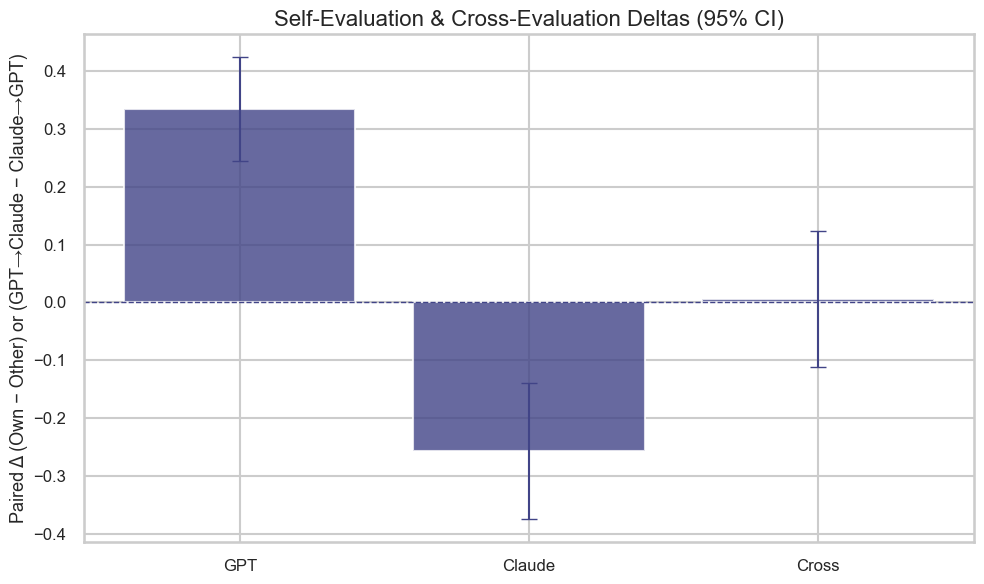


📊 Visualization saved: intra_model_bias_visualization_revised.png


In [17]:
# INTRA-MODEL BIAS & WITHIN-MODEL CONSISTENCY ANALYSIS — REVISED
import pandas as pd
import numpy as np
from scipy.stats import ttest_ind, ttest_rel, spearmanr, levene
import matplotlib.pyplot as plt
from statsmodels.stats.multitest import multipletests
import warnings
warnings.filterwarnings('ignore')

np.set_printoptions(suppress=True, floatmode="fixed")

print("=" * 80)
print("INTRA-MODEL BIAS & WITHIN-MODEL CONSISTENCY ANALYSIS (Revised)")
print("=" * 80)

# ------------------------------------------------------------------
# Load data
# ------------------------------------------------------------------
claude_df = pd.read_csv('/Users/jianzhouyao/AI4Good/Ratings/claude_response_with_ratings_updated.csv')
gpt_df    = pd.read_csv('/Users/jianzhouyao/AI4Good/Ratings/gpt_response_with_ratings_updated.csv')

# Add source labels (not strictly needed but handy)
claude_df['Response_Source'] = 'Claude'
gpt_df['Response_Source'] = 'GPT'

# Create age groups
for df in (claude_df, gpt_df):
    if 'age' in df.columns:
        df['age_group'] = pd.cut(
            df['age'],
            bins=[0, 18, 50, 65, 100],
            labels=['<18', '18-49', '50-64', '65+'],
            right=False
        )

print("📊 DATA OVERVIEW")
print("-" * 40)
print(f"Claude responses: {len(claude_df)} rows")
print(f"GPT responses: {len(gpt_df)} rows")

# ------------------------------------------------------------------
# Utilities
# ------------------------------------------------------------------
def mean_ci(x):
    x = np.asarray(x, dtype=float)
    x = x[~np.isnan(x)]
    n  = len(x)
    if n == 0:
        return np.nan, (np.nan, np.nan)
    m  = np.mean(x)
    s  = np.std(x, ddof=1) if n > 1 else 0.0
    se = s / np.sqrt(n) if n > 0 else np.nan
    ci = (m - 1.96*se, m + 1.96*se) if n > 1 else (m, m)
    return m, ci

def paired_test(series_a, series_b):
    """Aligned paired t-test + Cohen's dz + CI for the difference."""
    # Drop NaNs and align index
    df = pd.concat([series_a, series_b], axis=1, keys=['a', 'b']).dropna()
    a = df['a'].values
    b = df['b'].values
    n = len(df)
    if n < 3:
        return dict(n=n, diff=np.nan, p=np.nan, dz=np.nan, ci=(np.nan, np.nan))
    d = a - b
    m = np.mean(d)
    s = np.std(d, ddof=1)
    se = s / np.sqrt(n)
    ci = (m - 1.96*se, m + 1.96*se)
    t_stat, p_val = ttest_rel(a, b)
    dz = m / s if s > 0 else np.nan
    return dict(n=n, diff=m, p=p_val, dz=dz, ci=ci)

def welch_test(a, b):
    """Welch's t-test + Cohen's d (Hedges g-ish pooled via Welch not exact) + CI for diff."""
    a = np.asarray(a, dtype=float); a = a[~np.isnan(a)]
    b = np.asarray(b, dtype=float); b = b[~np.isnan(b)]
    n1, n2 = len(a), len(b)
    if n1 < 3 or n2 < 3:
        return dict(n1=n1, n2=n2, diff=np.nan, p=np.nan, d=np.nan, ci=(np.nan, np.nan))
    t_stat, p_val = ttest_ind(a, b, equal_var=False)
    diff = a.mean() - b.mean()
    # CI (Welch): use standard error via sample variances
    s1, s2 = a.var(ddof=1), b.var(ddof=1)
    se = np.sqrt(s1/n1 + s2/n2)
    ci = (diff - 1.96*se, diff + 1.96*se)
    # Effect size (Glass's delta-ish using pooled SD for reference)
    sp = np.sqrt(((n1-1)*s1 + (n2-1)*s2) / (n1+n2-2)) if (n1+n2-2)>0 else np.nan
    d = diff / sp if sp and sp>0 else np.nan
    return dict(n1=n1, n2=n2, diff=diff, p=p_val, d=d, ci=ci)

def iqr(x):
    x = pd.Series(x).dropna()
    return x.quantile(0.75) - x.quantile(0.25) if len(x) else np.nan

def align_on_prompt(a_df, a_col, b_df, b_col, key='Prompt Number', subset_mask_a=None, subset_mask_b=None):
    """Return two aligned Series on the same key (e.g., Prompt Number)."""
    A = a_df if subset_mask_a is None else a_df[subset_mask_a]
    B = b_df if subset_mask_b is None else b_df[subset_mask_b]
    A = A[[key, a_col]].dropna().set_index(key).sort_index()
    B = B[[key, b_col]].dropna().set_index(key).sort_index()
    joined = A.join(B, how='inner', lsuffix='_A', rsuffix='_B')
    return joined.iloc[:, 0], joined.iloc[:, 1]  # two aligned Series

# ------------------------------------------------------------------
# 1) SELF-EVALUATION BIAS (paired by prompt)
# ------------------------------------------------------------------
print("\n" + "=" * 80)
print("1. SELF-EVALUATION BIAS ANALYSIS (Paired by Prompt)")
print("=" * 80)

results = {}

# Affective (GPT rater): GPT→GPT vs GPT→Claude
a_gpt_gpt, b_gpt_claude = align_on_prompt(
    gpt_df,    'Affective Empathy Score (GPT)',
    claude_df, 'Affective Empathy Score (GPT)'
)
gpt_aff = paired_test(a_gpt_gpt, b_gpt_claude)
print("\n🔍 GPT Self-Evaluation (Affective):")
print(f"  GPT rating GPT vs GPT rating Claude (n={gpt_aff['n']}): "
      f"Δ={gpt_aff['diff']:+.3f}, 95%CI=({gpt_aff['ci'][0]:.3f},{gpt_aff['ci'][1]:.3f}), "
      f"p={gpt_aff['p']:.4g}, dz={gpt_aff['dz']:.3f}")
results['gpt_self_bias'] = gpt_aff['diff']
results['gpt_self_bias_p'] = gpt_aff['p']
results['gpt_self_bias_dz'] = gpt_aff['dz']

# Affective (Claude rater): Claude→Claude vs Claude→GPT
a_cl_claude, b_cl_gpt = align_on_prompt(
    claude_df, 'Affective Empathy Score (Claude)',
    gpt_df,    'Affective Empathy Score (Claude)'
)
cl_aff = paired_test(a_cl_claude, b_cl_gpt)
print("\n🔍 Claude Self-Evaluation (Affective):")
print(f"  Claude rating Claude vs Claude rating GPT (n={cl_aff['n']}): "
      f"Δ={cl_aff['diff']:+.3f}, 95%CI=({cl_aff['ci'][0]:.3f},{cl_aff['ci'][1]:.3f}), "
      f"p={cl_aff['p']:.4g}, dz={cl_aff['dz']:.3f}")
results['claude_self_bias'] = cl_aff['diff']
results['claude_self_bias_p'] = cl_aff['p']
results['claude_self_bias_dz'] = cl_aff['dz']

# Cognitive (GPT)
a_gpt_gpt_cog, b_gpt_claude_cog = align_on_prompt(
    gpt_df,    'Cognitive Empathy Score (GPT)',
    claude_df, 'Cognitive Empathy Score (GPT)'
)
gpt_cog = paired_test(a_gpt_gpt_cog, b_gpt_claude_cog)
print("\n🧠 GPT Self-Evaluation (Cognitive):")
print(f"  Δ={gpt_cog['diff']:+.3f}, 95%CI=({gpt_cog['ci'][0]:.3f},{gpt_cog['ci'][1]:.3f}), "
      f"p={gpt_cog['p']:.4g}, dz={gpt_cog['dz']:.3f}")

# Cognitive (Claude)
a_cl_claude_cog, b_cl_gpt_cog = align_on_prompt(
    claude_df, 'Cognitive Empathy Score (Claude)',
    gpt_df,    'Cognitive Empathy Score (Claude)'
)
cl_cog = paired_test(a_cl_claude_cog, b_cl_gpt_cog)
print("\n🧠 Claude Self-Evaluation (Cognitive):")
print(f"  Δ={cl_cog['diff']:+.3f}, 95%CI=({cl_cog['ci'][0]:.3f},{cl_cog['ci'][1]:.3f}), "
      f"p={cl_cog['p']:.4g}, dz={cl_cog['dz']:.3f}")

# ------------------------------------------------------------------
# 2) WITHIN-MODEL CONSISTENCY (SD, IQR; Levene test for variances)
# ------------------------------------------------------------------
print("\n" + "=" * 80)
print("2. WITHIN-MODEL CONSISTENCY ANALYSIS (SD, IQR, Levene)")
print("=" * 80)

def consistency_summary(series):
    s = pd.Series(series).dropna()
    return dict(n=len(s), mean=s.mean(), sd=s.std(ddof=1), iqr=iqr(s))

print("\n📏 GPT rating distributions (Affective):")
gpt_on_gpt = gpt_df['Affective Empathy Score (GPT)']
gpt_on_cla = claude_df['Affective Empathy Score (GPT)']
gpt_self_sum = consistency_summary(gpt_on_gpt)
gpt_other_sum = consistency_summary(gpt_on_cla)
print(f"  GPT→GPT:   n={gpt_self_sum['n']}, mean={gpt_self_sum['mean']:.3f}, SD={gpt_self_sum['sd']:.3f}, IQR={gpt_self_sum['iqr']:.3f}")
print(f"  GPT→Claude:n={gpt_other_sum['n']}, mean={gpt_other_sum['mean']:.3f}, SD={gpt_other_sum['sd']:.3f}, IQR={gpt_other_sum['iqr']:.3f}")
# Levene (Brown–Forsythe via median)
W_gpt, p_gpt = levene(gpt_on_gpt.dropna(), gpt_on_cla.dropna(), center='median')
print(f"  Variance difference test (Levene, median): W={W_gpt:.3f}, p={p_gpt:.4g}")
results['gpt_levene_p'] = p_gpt

print("\n🔍 Claude rating distributions (Affective):")
cla_on_cla = claude_df['Affective Empathy Score (Claude)']
cla_on_gpt = gpt_df['Affective Empathy Score (Claude)']
cla_self_sum = consistency_summary(cla_on_cla)
cla_other_sum = consistency_summary(cla_on_gpt)
print(f"  Claude→Claude: n={cla_self_sum['n']}, mean={cla_self_sum['mean']:.3f}, SD={cla_self_sum['sd']:.3f}, IQR={cla_self_sum['iqr']:.3f}")
print(f"  Claude→GPT:    n={cla_other_sum['n']}, mean={cla_other_sum['mean']:.3f}, SD={cla_other_sum['sd']:.3f}, IQR={cla_other_sum['iqr']:.3f}")
W_cla, p_cla = levene(cla_on_cla.dropna(), cla_on_gpt.dropna(), center='median')
print(f"  Variance difference test (Levene, median): W={W_cla:.3f}, p={p_cla:.4g}")
results['claude_levene_p'] = p_cla

# ------------------------------------------------------------------
# 3) DEMOGRAPHIC-SPECIFIC SELF-BIAS (paired by prompt) + FDR
# ------------------------------------------------------------------
print("\n" + "=" * 80)
print("3. DEMOGRAPHIC-SPECIFIC SELF-BIAS (Paired; BH-FDR correction)")
print("=" * 80)

demo_bias_results = {}
alpha = 0.05
min_pairs = 10  # stricter threshold than 3

def paired_bias_by_group(model_name, rater_col, own_df, other_df, demo_col):
    """
    For each group in demo_col: compare rater_col on own_df vs other_df,
    paired by prompt within that group.
    """
    pvals, labels, diffs, ns = [], [], [], []
    per_group = {}
    groups = sorted([g for g in pd.concat([own_df[demo_col], other_df[demo_col]]).dropna().unique()])
    for gval in groups:
        mask_own = own_df[demo_col] == gval
        mask_oth = other_df[demo_col] == gval
        a, b = align_on_prompt(own_df, rater_col, other_df, rater_col,
                               subset_mask_a=mask_own, subset_mask_b=mask_oth)
        pt = paired_test(a, b)
        if pt['n'] >= min_pairs:
            per_group[gval] = pt
            pvals.append(pt['p'])
            labels.append(str(gval))
            diffs.append(pt['diff'])
            ns.append(pt['n'])
        # silently skip groups with too-small n
    # FDR
    if len(pvals):
        reject, p_corr, _, _ = multipletests(pvals, alpha=alpha, method='fdr_bh')
        print(f"\n  {model_name} — {demo_col} (k={len(pvals)} groups; FDR-BH α={alpha}):")
        for lbl, raw_p, adj_p, rj, df_, n_ in zip(labels, pvals, p_corr, reject, diffs, ns):
            star = "✓" if rj else " "
            print(f"    {lbl:>25}: Δ={df_:+.3f}, n={n_:>3}, p={raw_p:.4g}, p_FDR={adj_p:.4g} {star}")
        # store summary
        demo_bias_results[f"{model_name}_{demo_col}_labels"] = labels
        demo_bias_results[f"{model_name}_{demo_col}_pvals_raw"] = pvals
        demo_bias_results[f"{model_name}_{demo_col}_pvals_fdr"] = p_corr.tolist()
        demo_bias_results[f"{model_name}_{demo_col}_diffs"] = diffs
        demo_bias_results[f"{model_name}_{demo_col}_ns"] = ns

for demo_col in ['gender', 'ethnicity', 'education', 'diagnosis', 'age_group']:
    if demo_col in gpt_df.columns and demo_col in claude_df.columns:
        # GPT rater self-bias within groups (Affective)
        paired_bias_by_group("GPT_rater_affective",
                             'Affective Empathy Score (GPT)',
                             gpt_df, claude_df, demo_col)
        # Claude rater self-bias within groups (Affective)
        paired_bias_by_group("Claude_rater_affective",
                             'Affective Empathy Score (Claude)',
                             claude_df, gpt_df, demo_col)

# ------------------------------------------------------------------
# 4) CROSS-EVALUATION ASYMMETRY (paired by prompt) + Spearman
# ------------------------------------------------------------------
print("\n" + "=" * 80)
print("4. CROSS-EVALUATION ASYMMETRY (Paired; Spearman agreement)")
print("=" * 80)

# Pair: GPT rating Claude vs Claude rating GPT on the same prompts
gpt_rates_claude, claude_rates_gpt = align_on_prompt(
    claude_df, 'Affective Empathy Score (GPT)',
    gpt_df,    'Affective Empathy Score (Claude)'
)
cross = paired_test(gpt_rates_claude, claude_rates_gpt)
print("\n⚖️ Cross-evaluation asymmetry (Affective):")
print(f"  GPT→Claude vs Claude→GPT (n={cross['n']}): "
      f"Δ={cross['diff']:+.3f}, 95%CI=({cross['ci'][0]:.3f},{cross['ci'][1]:.3f}), "
      f"p={cross['p']:.4g}, dz={cross['dz']:.3f}")

# Rank agreement on which prompts deserve higher empathy
if len(gpt_rates_claude) >= 3 and len(claude_rates_gpt) >= 3:
    rho, p_rho = spearmanr(gpt_rates_claude, claude_rates_gpt)
    print(f"  Cross-rater rank agreement (Spearman): ρ={rho:.3f}, p={p_rho:.4g}")
    results['cross_spearman_rho'] = rho
    results['cross_spearman_p'] = p_rho

# ------------------------------------------------------------------
# 5) RESPONSE–RATER INTERACTIONS (paired by prompt where sensible)
# ------------------------------------------------------------------
print("\n" + "=" * 80)
print("5. RESPONSE–RATER INTERACTION EFFECTS (Paired)")
print("=" * 80)

# Build aligned series for four cells
cc, cg = align_on_prompt(claude_df, 'Affective Empathy Score (Claude)', gpt_df, 'Affective Empathy Score (Claude)')  # Claude→Claude vs Claude→GPT
gg, gc = align_on_prompt(gpt_df,    'Affective Empathy Score (GPT)',    claude_df, 'Affective Empathy Score (GPT)')  # GPT→GPT vs GPT→Claude

print("\n📊 Summary means ± SD (unpaired descriptive):")
def msd(x): 
    x = pd.Series(x).dropna(); 
    return f"{x.mean():.3f} ± {x.std(ddof=1):.3f} (n={len(x)})"

print(f"  Claude→Claude: {msd(cc)}")
print(f"  Claude→GPT:    {msd(cg)}")
print(f"  GPT→GPT:       {msd(gg)}")
print(f"  GPT→Claude:    {msd(gc)}")

print("\n🔍 Paired contrasts by prompt:")
pt1 = paired_test(cc, cg)
print(f"  Claude self vs other:        Δ={pt1['diff']:+.3f}, p={pt1['p']:.4g}, dz={pt1['dz']:.3f}, n={pt1['n']}")
pt2 = paired_test(gg, gc)
print(f"  GPT self vs other:           Δ={pt2['diff']:+.3f}, p={pt2['p']:.4g}, dz={pt2['dz']:.3f}, n={pt2['n']}")
# Self (Claude) vs Self (GPT): pair by prompt using cc vs gg
pt3 = paired_test(cc, gg)
print(f"  Self-eval: Claude vs GPT:    Δ={pt3['diff']:+.3f}, p={pt3['p']:.4g}, dz={pt3['dz']:.3f}, n={pt3['n']}")
# Cross asymmetry already computed as cross

# ------------------------------------------------------------------
# 6) FINAL SUMMARY + SAVE
# ------------------------------------------------------------------
print("\n" + "=" * 80)
print("6. COMPREHENSIVE INTRA-MODEL BIAS SUMMARY")
print("=" * 80)

all_results = {
    **results,
    'gpt_self_bias': results.get('gpt_self_bias', np.nan),
    'gpt_self_bias_p': results.get('gpt_self_bias_p', np.nan),
    'gpt_self_bias_dz': results.get('gpt_self_bias_dz', np.nan),
    'claude_self_bias': results.get('claude_self_bias', np.nan),
    'claude_self_bias_p': results.get('claude_self_bias_p', np.nan),
    'claude_self_bias_dz': results.get('claude_self_bias_dz', np.nan),
    'levene_p_gpt': results.get('gpt_levene_p', np.nan),
    'levene_p_claude': results.get('claude_levene_p', np.nan)
}

# Flatten selected demographic summaries into a compact table (optional)
demo_rows = []
for k, v in demo_bias_results.items():
    if k.endswith('_labels'):
        base = k[:-7]  # strip _labels
        labels = demo_bias_results[k]
        raw   = demo_bias_results.get(base+'_pvals_raw', [])
        fdr   = demo_bias_results.get(base+'_pvals_fdr', [])
        diffs = demo_bias_results.get(base+'_diffs', [])
        ns    = demo_bias_results.get(base+'_ns', [])
        for lbl, p_raw, p_adj, dff, n_ in zip(labels, raw, fdr, diffs, ns):
            demo_rows.append(dict(family=base, group=lbl, n=n_, diff=dff, p_raw=p_raw, p_fdr=p_adj))
demo_df = pd.DataFrame(demo_rows)
demo_df.to_csv('demographic_self_bias_fdr.csv', index=False)

# Save top-level results
pd.DataFrame([all_results]).to_csv('intra_model_bias_results_revised.csv', index=False)

print("\n🔑 KEY FINDINGS (Affective, paired):")
print(f"  • GPT self-evaluation bias Δ (GPT→GPT – GPT→Claude): {gpt_aff['diff']:+.3f} "
      f"(p={gpt_aff['p']:.4g}, dz={gpt_aff['dz']:.3f})")
print(f"  • Claude self-evaluation bias Δ (Claude→Claude – Claude→GPT): {cl_aff['diff']:+.3f} "
      f"(p={cl_aff['p']:.4g}, dz={cl_aff['dz']:.3f})")
print(f"  • Cross-eval asymmetry Δ (GPT→Claude – Claude→GPT): {cross['diff']:+.3f} "
      f"(p={cross['p']:.4g}, dz={cross['dz']:.3f})")
print("\n💾 Saved:")
print("  • intra_model_bias_results_revised.csv")
print("  • demographic_self_bias_fdr.csv")

# ------------------------------------------------------------------
# Visualization (simple, consistent)
# ------------------------------------------------------------------
plt.figure(figsize=(10, 6))

# Bar 1: self-bias paired deltas
models = ['GPT', 'Claude', 'Cross']
deltas = [gpt_aff['diff'], cl_aff['diff'], cross['diff']]
yerr   = [ (gpt_aff['diff']-gpt_aff['ci'][0], gpt_aff['ci'][1]-gpt_aff['diff']),
           (cl_aff['diff']-cl_aff['ci'][0], cl_aff['ci'][1]-cl_aff['diff']),
           (cross['diff']-cross['ci'][0],   cross['ci'][1]-cross['diff']) ]
# Matplotlib expects asymmetric errors as 2xN array
yerr_arr = np.array([[e[0] for e in yerr], [e[1] for e in yerr]])

bars = plt.bar(models, deltas, alpha=0.8)
plt.errorbar(models, deltas, yerr=yerr_arr, fmt='none', capsize=6, linewidth=1.5)
plt.axhline(0, linestyle='--', linewidth=1)
plt.ylabel('Paired Δ (Own − Other) or (GPT→Claude − Claude→GPT)')
plt.title('Self-Evaluation & Cross-Evaluation Deltas (95% CI)')
plt.tight_layout()
plt.savefig('intra_model_bias_visualization_revised.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n📊 Visualization saved: intra_model_bias_visualization_revised.png")


In [28]:
# ==============================
# Self- vs Cross-Evaluation Deltas (95% CI)
# Consistent style + viridis palette + no title
# ==============================

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ==============================
# Global plotting style (same as your other plots)
# ==============================
sns.set(style="whitegrid")
sns.set_context("talk")  # base context
plt.rcParams.update({
    "font.size": 18,
    "axes.labelsize": 18,
    "xtick.labelsize": 18,
    "ytick.labelsize": 18,
    "legend.fontsize": 16,
    "figure.constrained_layout.use": True,
})

custom_palette = sns.color_palette("viridis", 4)  # consistent palette
sns.set_palette(custom_palette)

FIGSIZE = (10, 6)
DPI = 300

# ==============================
# Helper for CIs
# ==============================
def mean_ci_95(x):
    x = np.asarray(x, dtype=float)
    x = x[~np.isnan(x)]
    n = len(x)
    if n == 0:
        return np.nan, (np.nan, np.nan)
    m  = x.mean()
    sd = x.std(ddof=1) if n > 1 else 0.0
    se = sd / np.sqrt(n) if n > 0 else np.nan
    ci = (m - 1.96 * se, m + 1.96 * se) if n > 1 else (m, m)
    return m, ci

def ci_to_err(mean, ci):
    return (mean - ci[0], ci[1] - mean)

# ==============================
# Build paired deltas by prompt
# (Assumes aff_pivot already built as in previous code)
# ==============================
pair_gpt   = aff_pivot[[GP_GP, CL_GP]].dropna()
pair_cla   = aff_pivot[[CL_CL, GP_CL]].dropna()
pair_cross = aff_pivot[[CL_GP, GP_CL]].dropna()

delta_gpt   = (pair_gpt[GP_GP] - pair_gpt[CL_GP]).values
delta_cla   = (pair_cla[CL_CL] - pair_cla[GP_CL]).values
delta_cross = (pair_cross[CL_GP] - pair_cross[GP_CL]).values

m_gpt, ci_gpt     = mean_ci_95(delta_gpt)
m_cla, ci_cla     = mean_ci_95(delta_cla)
m_cross, ci_cross = mean_ci_95(delta_cross)

err_gpt   = ci_to_err(m_gpt, ci_gpt)
err_cla   = ci_to_err(m_cla, ci_cla)
err_cross = ci_to_err(m_cross, ci_cross)
yerr = np.array([[err_gpt[0], err_cla[0], err_cross[0]],
                 [err_gpt[1], err_cla[1], err_cross[1]]])

# ==============================
# Plot
# ==============================
labels = ["GPT", "Claude", "Cross"]
heights = [m_gpt, m_cla, m_cross]

plt.figure(figsize=FIGSIZE)
ax = plt.gca()

bars = ax.bar(labels, heights, alpha=0.9)
ax.errorbar(labels, heights, yerr=yerr, fmt='none', capsize=6, linewidth=1.8, color="black")

ax.axhline(0, linestyle="--", linewidth=1.2, alpha=0.7, color="black")
ax.set_ylabel("Paired Δ (Own − Other)\n(GPT→Claude − Claude→GPT for Cross)")


plt.tight_layout()
plt.savefig(output_folder / "self_cross_deltas.png", dpi=DPI, bbox_inches="tight")
plt.savefig(output_folder / "self_cross_deltas.pdf", bbox_inches="tight")
plt.close()

print("✅ Saved:", output_folder / "self_cross_deltas.png")


✅ Saved: /Users/jianzhouyao/AI4Good/Scoring_Charts/self_cross_deltas.png


In [47]:
# ==============================
# Readability Metrics — Unified Style (viridis, no titles, outside legend)
# Saves 4 figures to output_folder
# ==============================

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import seaborn as sns

# --- Global style (match your other figures) ---
sns.set(style="whitegrid")
sns.set_context("talk", font_scale=1.3)

plt.rcParams.update({
    "font.size": 26,
    "axes.labelsize": 26,
    "xtick.labelsize": 26,
    "ytick.labelsize": 26,
    "legend.fontsize": 22,
    "figure.constrained_layout.use": True,  # ok to keep; we'll still call tight_layout with rect
})

custom_palette = sns.color_palette("viridis", 4)  # consistent palette
sns.set_palette(custom_palette)

# Reuse your globals if already defined; else set defaults here
FIGSIZE = FIGSIZE if 'FIGSIZE' in globals() else (10, 6)
DPI = DPI if 'DPI' in globals() else 300
XTICK_ROT = XTICK_ROT if 'XTICK_ROT' in globals() else 15

# Helper: place legend outside (right)
def place_legend_outside(ax, title=None, loc="upper left"):
    ax.legend(title=title, bbox_to_anchor=(1.02, 1), loc=loc, borderaxespad=0)

width = 0.35  # bar width

# ------------------------------------------------
# Plot 1: Overall Metric Comparison (with cap stripes)
# ------------------------------------------------
metrics = ["Flesch-Kincaid", "SMOG Index", "Gunning Fog"]
gpt_all = [9.72, 12.59, 11.86]
claude_all = [9.54, 12.13, 11.70]
scale_limits = [12, 18, 20]  # per-metric upper guidance

x = np.arange(len(metrics))
fig, ax = plt.subplots(figsize=FIGSIZE)

# Colors from viridis palette (consistent assignment)
color_claude = custom_palette[1]
color_gpt    = custom_palette[2]

bars_cla = ax.bar(x - width/2, claude_all, width, label='Claude', color=color_claude)
bars_gpt = ax.bar(x + width/2, gpt_all,    width, label='GPT',    color=color_gpt)

# Draw small horizontal “cap” stripes at scale limits for both bars at each metric
def draw_horizontal_stripes(ax, x_center, y_level, total_width, n_stripes=7, stripe_len_frac=0.25):
    spacing = total_width / n_stripes
    start_x = x_center - total_width / 2
    stripe_len = stripe_len_frac * spacing
    for i in range(n_stripes):
        x_start = start_x + i * spacing
        x_end = x_start + stripe_len
        ax.hlines(y=y_level, xmin=x_start, xmax=x_end, color='black', linewidth=1)

for i, limit in enumerate(scale_limits):
    # center each group bar at its bar center
    draw_horizontal_stripes(ax, x[i] - width/2, limit, width)
    draw_horizontal_stripes(ax, x[i] + width/2, limit, width)

# Value labels
for bars in [bars_cla, bars_gpt]:
    for bar in bars:
        ax.annotate(f'{bar.get_height():.2f}',
                    xy=(bar.get_x() + bar.get_width()/2, bar.get_height()),
                    xytext=(0, 3), textcoords="offset points",
                    ha='center', va='bottom', fontsize=14)

# Axes formatting (no title)
ax.set_ylabel('Grade Level')
ax.set_xticks(x)
ax.set_xticklabels(metrics, rotation=XTICK_ROT, ha='right')

# Legend with cap line key, placed outside
scale_line = Line2D([0], [0], color='black', linewidth=1, label='Scale Limit')
handles = [bars_cla, bars_gpt, scale_line]
labels  = ['Claude', 'GPT', 'Scale Limit']
ax.legend(handles=handles, labels=labels, title=None, bbox_to_anchor=(1.02, 1), loc="upper left", borderaxespad=0)

plt.tight_layout()
plt.savefig(output_folder / "readability_overall_metrics.png", dpi=DPI, bbox_inches="tight")

plt.close()


# ------------------------------------------------
# Plot 2: Education Level — Flesch-Kincaid
# ------------------------------------------------
education_levels = ["High school", "University", "Medical"]
gpt_scores_edu = [8.29, 10.03, 11.19]
claude_scores_edu = [6.81, 10.44, 12.05]
x = np.arange(len(education_levels))

fig, ax = plt.subplots(figsize=FIGSIZE)

bars_gpt = ax.bar(x - width/2, gpt_scores_edu,    width, label='GPT',    color=color_gpt)
bars_cla = ax.bar(x + width/2, claude_scores_edu, width, label='Claude', color=color_claude)

# Value labels
for bars in [bars_gpt, bars_cla]:
    for bar in bars:
        ax.annotate(f'{bar.get_height():.2f}',
                    (bar.get_x() + bar.get_width()/2, bar.get_height()),
                    textcoords="offset points", xytext=(0, 3),
                    ha='center', va='bottom', fontsize=14)

ax.set_ylabel('Grade Level')
ax.set_ylim(0, 14)
ax.set_xticks(x)
ax.set_xticklabels(education_levels, rotation=XTICK_ROT, ha='right')
place_legend_outside(ax)

plt.tight_layout()
plt.savefig(output_folder / "readability_by_education_fk.png", dpi=DPI, bbox_inches="tight")

plt.close()


# ------------------------------------------------
# Plot 3: Ethnicity — SMOG Index (sorted by average)
# ------------------------------------------------
ethnicities = ["European", "African", "Asian"]
gpt_scores_eth = [12.76, 12.37, 12.63]
claude_scores_eth = [12.39, 12.03, 11.97]
avg_eth = [(g + c) / 2 for g, c in zip(gpt_scores_eth, claude_scores_eth)]
sorted_idx = np.argsort(avg_eth)
eth_sorted = [ethnicities[i] for i in sorted_idx]
gpt_sorted = [gpt_scores_eth[i] for i in sorted_idx]
claude_sorted = [claude_scores_eth[i] for i in sorted_idx]
x = np.arange(len(eth_sorted))

fig, ax = plt.subplots(figsize=FIGSIZE)

bars_gpt = ax.bar(x - width/2, gpt_sorted,    width, label='GPT',    color=color_gpt)
bars_cla = ax.bar(x + width/2, claude_sorted, width, label='Claude', color=color_claude)

for bars in [bars_gpt, bars_cla]:
    for bar in bars:
        ax.annotate(f'{bar.get_height():.2f}',
                    (bar.get_x() + bar.get_width()/2, bar.get_height()),
                    textcoords="offset points", xytext=(0, 3),
                    ha='center', va='bottom', fontsize=14)

ax.set_ylabel('SMOG Index')
ax.set_ylim(0, 14)
ax.set_xticks(x)
ax.set_xticklabels(eth_sorted, rotation=XTICK_ROT, ha='right')
place_legend_outside(ax)

plt.tight_layout()
plt.savefig(output_folder / "readability_by_ethnicity_smog.png", dpi=DPI, bbox_inches="tight")

plt.close()


# ------------------------------------------------
# Plot 4: Gender — Gunning Fog
# ------------------------------------------------
genders = ["Female", "Male"]
gpt_scores_gen = [11.99, 11.73]
claude_scores_gen = [11.61, 11.78]
x = np.arange(len(genders))

fig, ax = plt.subplots(figsize=FIGSIZE)

# Keep legend in lower-left if outside would clip; otherwise place outside
bars_gpt = ax.bar(x - width/2, gpt_scores_gen,    width, label='GPT',    color=color_gpt)
bars_cla = ax.bar(x + width/2, claude_scores_gen, width, label='Claude', color=color_claude)

for bars in [bars_gpt, bars_cla]:
    for bar in bars:
        ax.annotate(f'{bar.get_height():.2f}',
                    (bar.get_x() + bar.get_width()/2, bar.get_height()),
                    textcoords="offset points", xytext=(0, 3),
                    ha='center', va='bottom', fontsize=14)

ax.set_ylabel('Gunning Fog')
ax.set_ylim(0, 14)
ax.set_xticks(x)
ax.set_xticklabels(genders, rotation=XTICK_ROT, ha='right')
# Outside legend for consistency (move inside if it clips in your layout)
place_legend_outside(ax, loc="upper left")

plt.tight_layout()
plt.savefig(output_folder / "readability_by_gender_gf.png", dpi=DPI, bbox_inches="tight")

plt.close()

print("✅ Saved 4 readability figures to:", output_folder)


✅ Saved 4 readability figures to: /Users/jianzhouyao/AI4Good/Scoring_Charts
